## Semantic Search, Similarity & Clustering with Sentence Transformers

In this tutorial, we will work with sentence transformers. First, we will load a corpus of text documents and compute sentence embeddings using a pretrained Sentence Transformer. Then, we will perform semantic search, compute document similarity, and apply clustering (e.g., K-means). Next, we will visualise clusters formed. We will use Hugging Face and SentenceTransformers library, which provides powerful pretrained embedding models for semantic tasks.

### What We Are Going to Cover:

-  Loading or generating a collection of text documents
-  Encoding text into vectors (embeddings)
-  Semantic search (finding similar docs)
-  Similarity ranking
-  Clustering documents (grouping by topic)
-  Visualising clusters

### Key Learnings

By the end of this notebook, learners are expected to understand:

- What sentence embeddings are
- How semantic search works using embedding similarity
- How to cluster documents using vector representations
- How to visualise clusters with dimensionality reduction methods like PCA

**Let us get started**

### Understanding Sentence Embeddings: A Visual Explanation

Before we dive into code, let's understand what sentence embeddings are and why they're powerful. The following diagram illustrates the core concept.

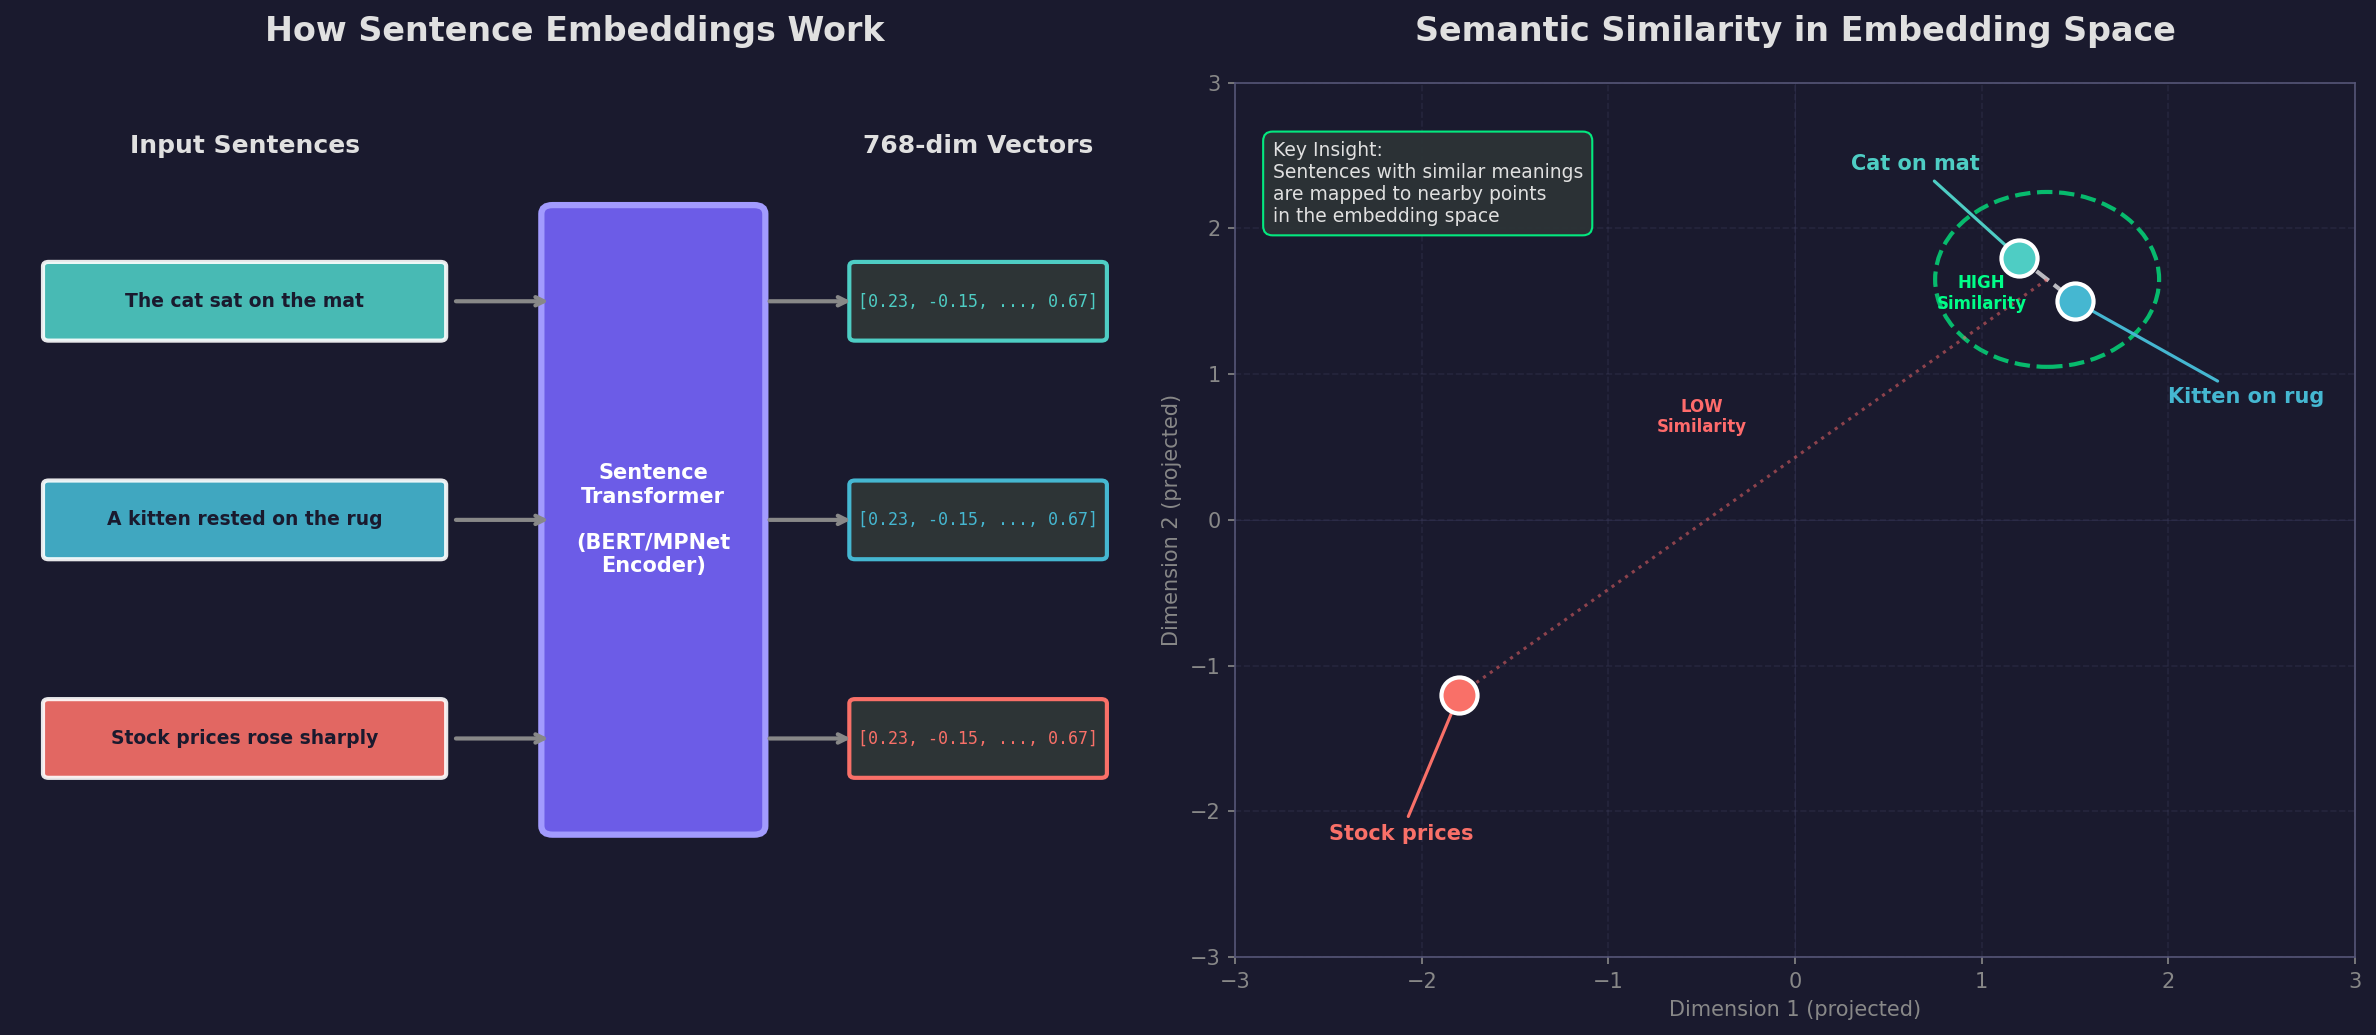

In [4]:
from IPython.display import Image, display
display(Image(filename='/content/sentence_embedding_concept.png'))

#### What the Diagram Shows

**Left Panel - The Encoding Process:**
- **Input:** Raw text sentences of varying lengths and vocabulary
- **Encoder:** The Sentence Transformer (based on architectures like BERT or MPNet) processes each sentence
- **Output:** Fixed-size numerical vectors (768 dimensions for `all-mpnet-base-v2`)

**Right Panel - Semantic Similarity in Vector Space:**
- Each point represents a sentence's position in the high-dimensional embedding space (projected to 2D for visualisation)
- **Similar sentences cluster together:** "Cat sat on mat" and "Kitten rested on rug" are semantically similar, so they appear close in the space
- **Dissimilar sentences are far apart:** "Stock prices rose sharply" has completely different meaning, so it's located far from the animal sentences

**Why This Matters:**
1. **Semantic Search:** Find documents by meaning, not just keywords
2. **Similarity Scoring:** Measure how related two pieces of text are using vector distance (cosine similarity)
3. **Clustering:** Group similar documents automatically based on their positions in embedding space

With this understanding, let us work on applying sentence transformers with more data.

### Install and Import Libraries
First, we need the sentence-transformers library from Hugging Face for the embeddings and scikit-learn for clustering.

In [2]:
!pip install -U sentence-transformers pandas matplotlib umap-learn --quiet


In [3]:
# Import Libraries
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

### Dataset
We will load from Hugging Face dataset. This is a sample dataset containing a bunch of documents. You can also use your own dataset for this exercise.

In [4]:
import numpy as np
from datasets import load_dataset

# Loads only the first 300 samples from the 'train' split
dataset = load_dataset("ag_news", split="train[:300]")
texts = dataset["text"]  # list of text strings

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [5]:
len(texts)

300

This gives you ~300 short documents — a great sample dataset to learn with.

In [6]:
# Sample text document
print(texts[90])

Science, Politics Collide in Election Year (AP) AP - With more than 4,000 scientists, including 48 Nobel Prize winners, having signed a statement opposing the Bush administration's use of scientific advice, this election year is seeing a new development in the uneasy relationship between science and politics.


### Sentence Transformer Model

We will use `all-mpnet-base-v2`, a sentence transformer model that maps sentences & paragraphs to a 768 dimensional dense vector space and can be used for tasks like clustering or semantic search. It is widely regarded as the highest-quality model in the "all" family of Sentence Transformers, prioritising accuracy over the smaller, faster models like `all-MiniLM-L6-v2`.

This model is based on `microsoft/mpnet-base` architecture and fine-tuned on over 1.17 billion sentence pairs using a self-supervised contrastive learning objective. It has a max input length of 384 word-piece tokens (approx. 280 words). This model processes approximately 2,800 sentences per second on modern hardware, making it slower but more accurate than lighter alternatives.

In [7]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-mpnet-base-v2')

Next, let us embed all the text documents using this model.

In [8]:
embeddings = model.encode(texts, convert_to_tensor=True)

In [9]:
embeddings.shape

torch.Size([300, 768])

Result: (300, 768) - 300 documents, each represented by vectors having 768 numbers.

In [10]:
embeddings = model.encode(texts)
len(embeddings)

300

### Semantic Search
Unlike keyword search, semantic search finds the meaning. We will search for a concept that doesn't use the exact words from our list.

In [11]:
def semantic_search(query):
    q_vec = model.encode([query])[0]
    scores = np.dot(embeddings, q_vec)
    ranked_idxs = np.argsort(scores)[::-1]
    ranked_idxs = list(ranked_idxs)

    return [(texts[int(i)], float(scores[int(i)])) for i in ranked_idxs[:5]]

semantic_search("What are the latest space news from NASA")

[("New NASA Supercomputer to Aid Theorists and Shuttle Engineers (SPACE.com) SPACE.com - NASA researchers have teamed up with a pair of Silicon Valley firms to build \\  a supercomputer that ranks alongside the world's largest Linux-based systems.",
  0.5398959517478943),
 ('Redesigning Rockets: NASA Space Propulsion Finds a New Home (SPACE.com) SPACE.com - While the exploration of the Moon and other planets in our solar system is nbsp;exciting, the first task for astronauts and robots alike is to actually nbsp;get to those destinations.',
  0.4978867173194885),
 ('Website Lets Users Scout the Red Planet from Home (SPACE.com) SPACE.com - For those who want to explore Mars but cant wait for a spacecraft to take them there, NASA scientists have reformulated a website that lets the general public search data and images from previous missions.',
  0.48406872153282166),
 ("NASA Chief: 'Let's Go Save the Hubble' (SPACE.com) SPACE.com - Amid uncertainty over the fate of the Hubble Space Teles

This returns the top 5 most semantically similar docs.

### Document Similarity (Pairwise)
This is used to find which documents are "twins" or very related to each other. Commonly used during de-duplication of documents.

In [12]:
# Compute similarity for every document against every other document
sim_matrix = util.cos_sim(embeddings, embeddings)

# Let's find what is most similar to Document #10 (Neural Networks)
doc_idx = 10
scores = sim_matrix[doc_idx]
best_match = np.argsort(scores.cpu())[-2] # -1 is itself, -2 is the next best

print(f"Original: {texts[doc_idx]}")
print(f"Most Similar: {texts[int(best_match)]} (Score: {scores[int(best_match)]:.4f})")

Original: Oil and Economy Cloud Stocks' Outlook  NEW YORK (Reuters) - Soaring crude prices plus worries  about the economy and the outlook for earnings are expected to  hang over the stock market next week during the depth of the  summer doldrums.
Most Similar: Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums. (Score: 0.9757)


### Unsupervised Clustering
We will use K-Means to see if the AI can group these 300 documents back into their 9 clusters without us telling it the labels.

In [13]:
# We expect 9 clusters
num_clusters = 9 # We can also alter this based on the number of clusters that we want
clustering_model = KMeans(n_clusters=num_clusters, random_state=42)
clustering_model.fit(embeddings)
cluster_assignment = clustering_model.labels_

# Grouping results
for i in range(num_clusters):
    print(f"\n--- Cluster {i} ---")
    for idx, label in enumerate(cluster_assignment):
        if label == i:
            print(f"- {texts[idx][:60]}...")


--- Cluster 0 ---
- IT alligator tales I grew up in New York, where giant alliga...
- T. Rex Had Teen Growth Spurt, Scientists Say (Reuters) Reute...
- Dolphins Too Have Born Socialites (Reuters) Reuters - Some p...
- Studies Find Rats Can Get Hooked on Drugs (AP) AP - Rats can...
- Rescuers Free Beached Whale in Brazil (AP) AP - Rescuers suc...
- Red-Footed Falcon Sighted in Mass. (AP) AP - A red-footed fa...
- Growth, Mortality of T. Rex Gets Clearer (AP) AP - Here's a ...
- U.S. Barred From Weakening Dolphin Rules (AP) AP - In a vict...
- Aquarium Reviews Death of Dolphin (AP) AP - The chief scient...
- Southeast Coast Sees Fewer Turtle Nests (AP) AP - About half...
- Chorus Frog Found Croaking in Virginia (AP) AP - The Souther...
- Marine Expedition Finds New Species (AP) AP - Norwegian scie...
- Poachers Putting Endangered Rhinos at Risk (AP) AP - Gangs o...
- Experts Downplay Texas Shark Attacks (AP) AP - Three shark a...
- Study Says Birds Feed Other Birds' Young (AP) AP - It's

Clustering groups similar documents together

### Visualisation using t-SNE (t-Distributed Stochastic Neighbor Embedding)

#### What is t-SNE?

**t-SNE** is a dimensionality reduction technique specifically designed for visualising high-dimensional data in 2D or 3D. Unlike PCA (which preserves global variance), t-SNE focuses on preserving **local neighborhood structure** — meaning points that are close together in high-dimensional space remain close in the visualisation.

#### How t-SNE Works:

1. **Compute pairwise similarities** in the original high-dimensional space (768D for our embeddings)
2. **Create a probability distribution** where similar points have high probability of being "neighbours"
3. **Optimise a 2D layout** where the neighborhood probabilities are preserved as much as possible
4. Uses a **Student's t-distribution** (hence the "t" in t-SNE) in the low-dimensional space to handle the "crowding problem"

#### Why t-SNE is Better for Sentence Embeddings:

| Aspect | PCA | t-SNE |
|--------|-----|-------|
| **Preserves** | Global variance/spread | Local neighbourhoods |
| **Cluster separation** | Often poor | Excellent |
| **Non-linear patterns** | Cannot capture | Captures well |
| **Interpretation** | Axes have meaning | Axes are arbitrary |
| **Speed** | Very fast | Slower (O(n²)) |

**Key insight:** Sentence embeddings live on a complex, non-linear manifold. t-SNE excels at unfolding this manifold to reveal cluster structure that PCA would miss.

#### Important t-SNE Parameters:
- **`perplexity`** (5-50): Balance between local and global structure. Higher = considers more neighbors
- **`n_iter`**: Number of optimisation iterations. More = better convergence
- **`learning_rate`**: Step size for optimisation. Usually 10-1000

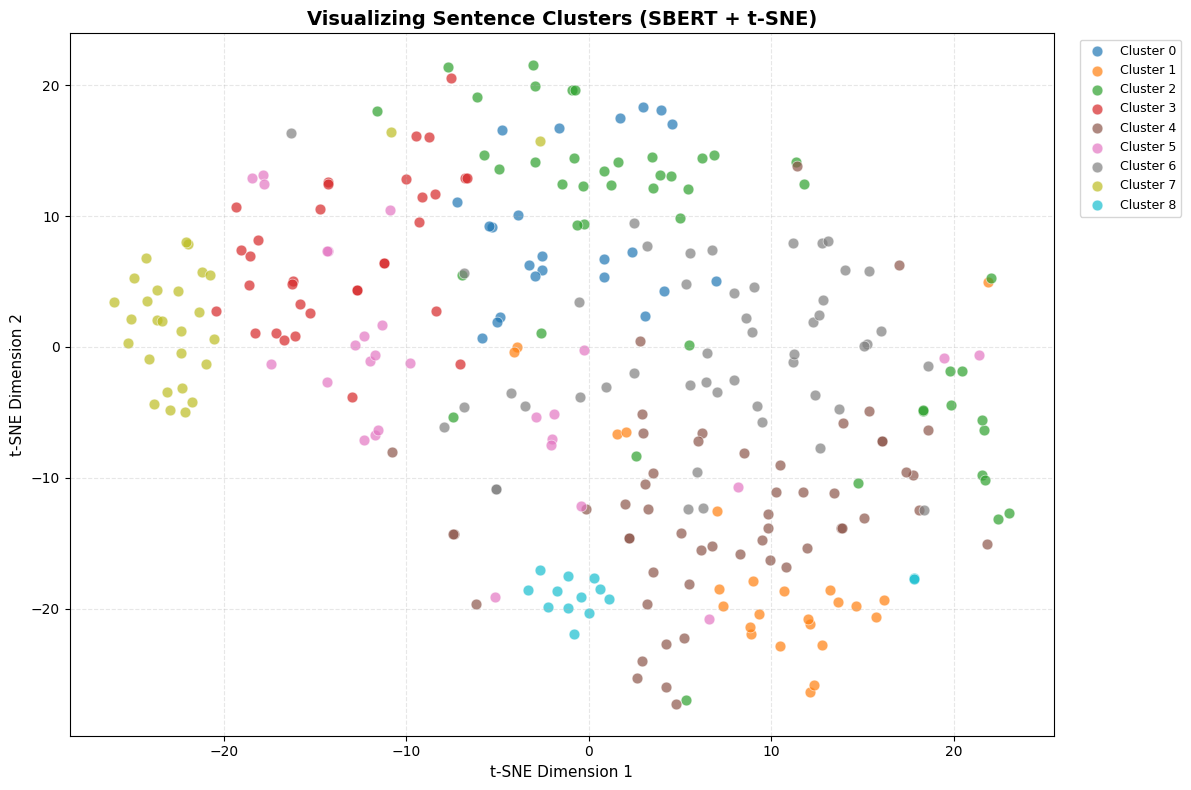


✓ Reduced 768-dimensional embeddings to 2D using t-SNE
✓ Visualized 300 documents across 9 clusters


In [ ]:
from sklearn.manifold import TSNE

# Initialise t-SNE with recommended parameters for sentence embeddings
tsne = TSNE(
    n_components=2,          # Reduce to 2D for visualization
    perplexity=30,           # Number of nearest neighbors to consider (typical: 5-50)
    learning_rate='auto',    # Automatically set based on dataset size
    init='pca',              # Initialise with PCA for better convergence
    random_state=42          # For reproducibility
)

# Fit and transform the embeddings
reduced_embeddings = tsne.fit_transform(embeddings)

# Create visualisation with custom styling
plt.figure(figsize=(12, 8))
plt.style.use('default')

# Define a colormap with distinct colors for each cluster
colors = plt.cm.tab10(np.linspace(0, 1, num_clusters))

for i in range(num_clusters):
    mask = cluster_assignment == i
    points = reduced_embeddings[mask]
    plt.scatter(
        points[:, 0],
        points[:, 1],
        c=[colors[i]],
        label=f'Cluster {i}',
        alpha=0.7,
        s=60,
        edgecolors='white',
        linewidth=0.5
    )

plt.title("Visualising Sentence Clusters (SBERT + t-SNE)", fontsize=14, fontweight='bold')
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\n✓ Reduced {embeddings.shape[1]}-dimensional embeddings to 2D using t-SNE")
print(f"✓ Visualised {len(embeddings)} documents across {num_clusters} clusters")

#### Interpreting the t-SNE Visualisation

**What you should observe:**
- Documents in the same cluster (same color) should appear grouped together
- Well-separated clusters indicate that the K-Means algorithm found meaningful semantic groupings
- Overlapping clusters suggest those topics share semantic similarities

**Important caveats about t-SNE:**
1. **Distances between clusters are NOT meaningful** — only distances within clusters matter
2. **Cluster sizes can be distorted** — t-SNE may artificially inflate or shrink cluster sizes
3. **Results vary with perplexity** — try different values (5, 30, 50) to see how the visualisation changes
4. **It's non-deterministic** — without a fixed `random_state`, you'll get different layouts each run

Despite these caveats, t-SNE remains one of the most effective tools for visualising high-dimensional embeddings because it reveals the local structure that makes sentence embeddings powerful for semantic tasks.

### Conclusion
In this notebook, we encoded text to vectors using sentence transformers from huggingface. We performed semantic search and computed similarity checks. We clustered documents using K-Means and visualised them using dimensionality reduction method such as tSNE.